# **Fake Review Analysis**



In [1]:
from google.colab import files
uploaded = files.upload()

Saving fake_reviews_50k.csv.csv to fake_reviews_50k.csv.csv


In [2]:
import pandas as pd

df = pd.read_csv("fake_reviews_50k.csv.csv")
df.head()

,review_id,user_id,product_id,rating,review_text,review_date,verified_purchase,helpful_votes,review_length,sentiment_score,is_fake
0,1,2343,664,1,Not as described,29-12-2022,0,140,16,0.317,0
1,2,1752,453,2,Stopped working after few days,03-09-2022,0,150,30,0.234,0
2,3,5227,965,4,"Great product, highly recommend",04-08-2024,1,79,31,0.822,0
3,4,5827,529,2,Stopped working after few days,04-09-2023,0,166,30,0.251,0
4,5,4057,73,3,Product is okay,18-11-2023,1,22,15,-0.981,0


In [3]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   review_id          50000 non-null  int64  
 1   user_id            50000 non-null  int64  
 2   product_id         50000 non-null  int64  
 3   rating             50000 non-null  int64  
 4   review_text        50000 non-null  object 
 5   review_date        50000 non-null  object 
 6   verified_purchase  50000 non-null  int64  
 7   helpful_votes      50000 non-null  int64  
 8   review_length      50000 non-null  int64  
 9   sentiment_score    50000 non-null  float64
 10  is_fake            50000 non-null  int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 4.2+ MB


,0
review_id,0
user_id,0
product_id,0
rating,0
review_text,0
review_date,0
verified_purchase,0
helpful_votes,0
review_length,0
sentiment_score,0


In [4]:
!pip install scikit-learn nltk seaborn

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


DATA CLEANING

In [6]:
df = df.drop_duplicates()

df['review_text'] = df['review_text'].str.lower()

df.isnull().sum()

,0
review_id,0
user_id,0
product_id,0
rating,0
review_text,0
review_date,0
verified_purchase,0
helpful_votes,0
review_length,0
sentiment_score,0


In [7]:
df["review_length"] = df["review_text"].apply(len)

df["word_count"] = df["review_text"].apply(lambda x: len(x.split()))

df["rating_deviation"] = abs(df["rating"] - df["rating"].mean())
df.head()

,review_id,user_id,product_id,rating,review_text,review_date,verified_purchase,helpful_votes,review_length,sentiment_score,is_fake,word_count,rating_deviation
0,1,2343,664,1,not as described,29-12-2022,0,140,16,0.317,0,3,1.99696
1,2,1752,453,2,stopped working after few days,03-09-2022,0,150,30,0.234,0,5,0.99696
2,3,5227,965,4,"great product, highly recommend",04-08-2024,1,79,31,0.822,0,4,1.00304
3,4,5827,529,2,stopped working after few days,04-09-2023,0,166,30,0.251,0,5,0.99696
4,5,4057,73,3,product is okay,18-11-2023,1,22,15,-0.981,0,3,0.00304


Exploratory Visualization
Rating Distribution

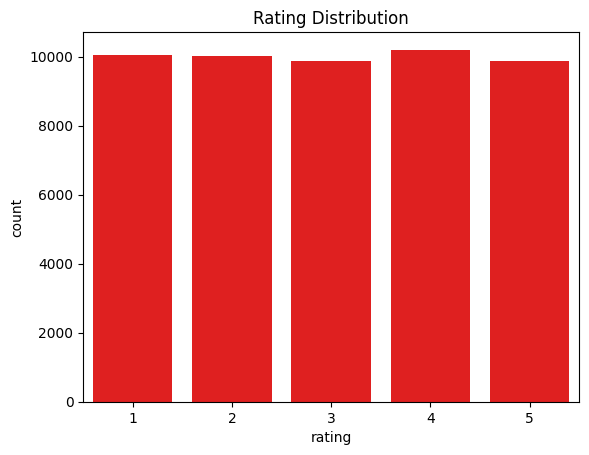

In [8]:
sns.countplot(x="rating", data=df,color = "red")
plt.title("Rating Distribution")
plt.show()

Fake vs Genuine Reviews

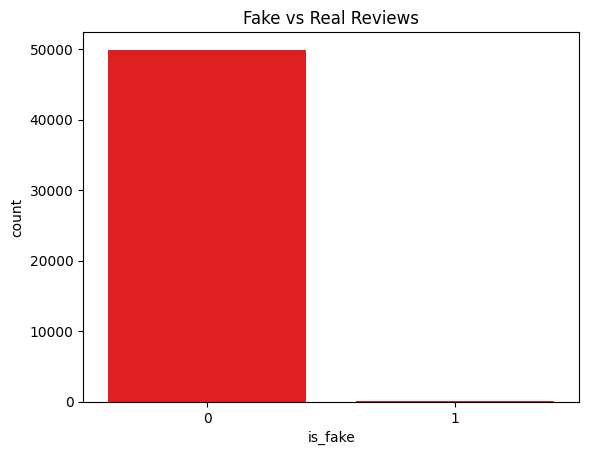

In [9]:
sns.countplot(x="is_fake", data=df,color = "red")
plt.title("Fake vs Real Reviews")
plt.show()

Text Vectorization (NLP)

In [10]:
tfidf =TfidfVectorizer(
    stop_words = "english",
    max_features = 1000
)
x_text = tfidf.fit_transform(df["review_text"])


combine features

In [11]:
numerical_features = df[[
    "rating",
    "helpful_votes",
    "word_count",
    "sentiment_score"
]]
from scipy.sparse import hstack
x = hstack((x_text, numerical_features))
y = df["is_fake"]
df.head()

,review_id,user_id,product_id,rating,review_text,review_date,verified_purchase,helpful_votes,review_length,sentiment_score,is_fake,word_count,rating_deviation
0,1,2343,664,1,not as described,29-12-2022,0,140,16,0.317,0,3,1.99696
1,2,1752,453,2,stopped working after few days,03-09-2022,0,150,30,0.234,0,5,0.99696
2,3,5227,965,4,"great product, highly recommend",04-08-2024,1,79,31,0.822,0,4,1.00304
3,4,5827,529,2,stopped working after few days,04-09-2023,0,166,30,0.251,0,5,0.99696
4,5,4057,73,3,product is okay,18-11-2023,1,22,15,-0.981,0,3,0.00304


Train Test Split

In [12]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,
    test_size = 0.2,
    random_state = 42
)

Train Machine Learning Model

In [13]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(x_train, y_train)


RandomForestClassifier(random_state=42)

predictions

In [14]:
y_pred = model.predict(x_test)

Fake Probability Score

In [15]:
df["fake_probability"] = model.predict_proba(x)[:,1]

model evaluation

In [16]:
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9989


Classification Report

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9987
           1       0.58      0.54      0.56        13

    accuracy                           1.00     10000
   macro avg       0.79      0.77      0.78     10000
weighted avg       1.00      1.00      1.00     10000



Cunfusion matix

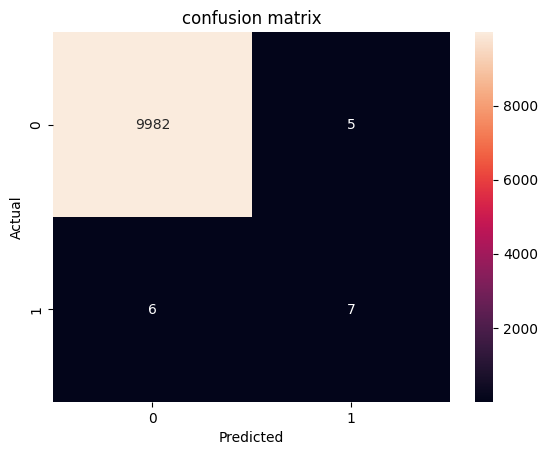

In [18]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,annot= True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("confusion matrix")
plt.show()

Fake review probablity score

In [19]:
df["fake_probability"] = model.predict_proba(x)[:,1]
df[["review_text","fake_probability"]].head()

,review_text,fake_probability
0,not as described,0.0
1,stopped working after few days,0.0
2,"great product, highly recommend",0.0
3,stopped working after few days,0.0
4,product is okay,0.0


Top Suspicious Reviews

In [20]:
suspicious_reviews = df.sort_values(
    by="fake_probability",
    ascending=False
)

suspicious_reviews.head(20)

,review_id,user_id,product_id,rating,review_text,review_date,verified_purchase,helpful_votes,review_length,sentiment_score,is_fake,word_count,rating_deviation,fake_probability
16678,16679,606,234,5,very satisfied with this purchase,31-07-2023,0,0,33,0.751,1,5,2.00304,0.9900
5081,5082,1922,373,5,very satisfied with this purchase,17-08-2024,0,0,33,0.330,1,5,2.00304,0.9875
30899,30900,7175,1165,5,works perfectly and looks great,15-10-2022,0,1,31,0.892,1,5,2.00304,0.9800
29480,29481,2187,737,5,very satisfied with this purchase,18-08-2023,0,0,33,0.701,1,5,2.00304,0.9700
48013,48014,7218,1156,5,amazing product and good value,27-09-2024,0,0,30,0.731,1,5,2.00304,0.9700
48542,48543,2263,940,5,very satisfied with this purchase,04-07-2024,0,0,33,0.328,1,5,2.00304,0.9675
34658,34659,298,417,5,works perfectly and looks great,08-04-2023,0,1,31,0.957,1,5,2.00304,0.9600
30574,30575,5789,416,5,very satisfied with this purchase,09-01-2023,0,0,33,0.354,1,5,2.00304,0.9575
28590,28591,2770,137,5,amazing product and good value,21-05-2024,1,0,30,0.952,0,5,2.00304,0.9500
38848,38849,94,72,5,amazing product and good value,08-04-2024,0,0,30,0.758,1,5,2.00304,0.9500


#Review Distribution

What is the distribution of ratings?

Which rating appears most frequently?

What is the average rating per product?

What is the average rating per user?

Which product has the highest rating?

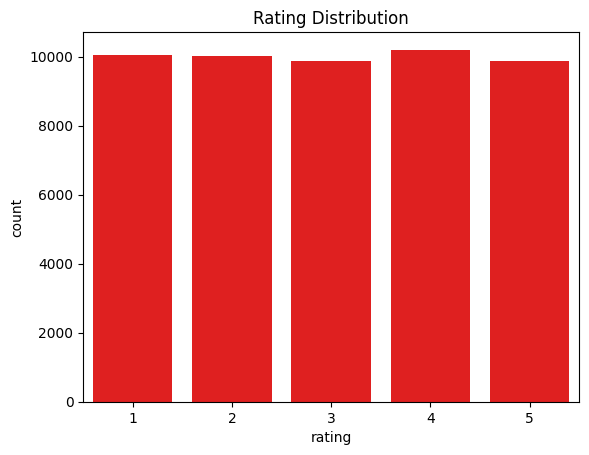

In [21]:
# what is the distribution of rating
sns.countplot(x="rating", data=df, color="red")
plt.title("Rating Distribution")
plt.show()

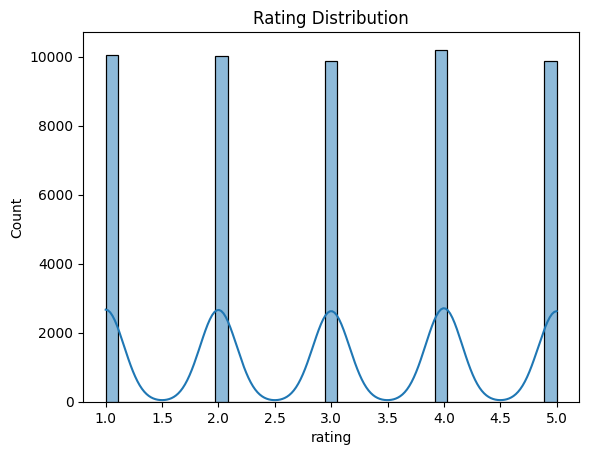

In [22]:
#Which rating appears most frequently?
sns.histplot(df["rating"], kde=True)
plt.title("Rating Distribution")
plt.show()

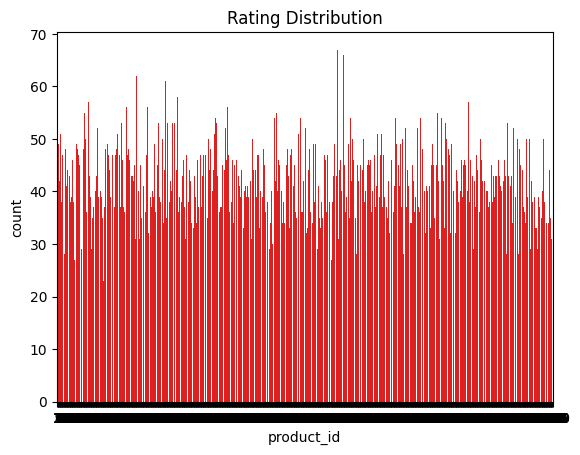

In [23]:
#what is average rating per product?
sns.countplot(x="product_id", data=df, color="red")
plt.title("Rating Distribution")
plt.show()

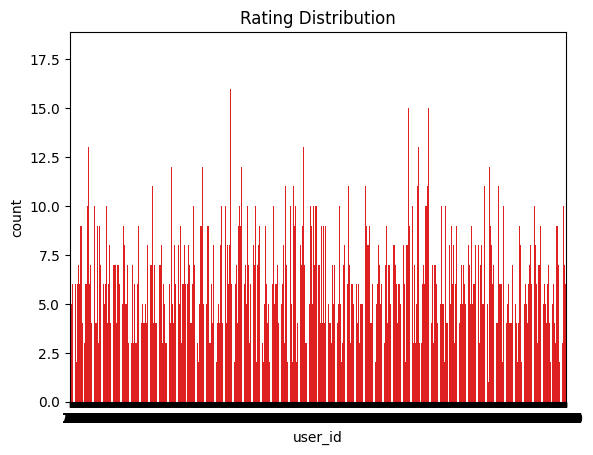

In [24]:
#what is average per user?
sns.countplot(x="user_id", data=df, color="red")
plt.title("Rating Distribution")
plt.show()

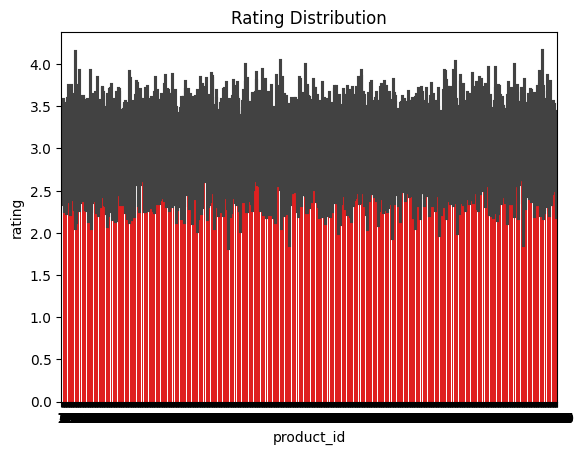

In [25]:
# Which product has the highest rating?
sns.barplot(x="product_id", y="rating", data=df, color="red")
plt.title("Rating Distribution")
plt.show()

#User Behaviour

Which user wrote the most reviews?

Which users write reviews very frequently?

Which users write reviews for many products?

Which users only write 5-star reviews?

Which users write mostly negative reviews?

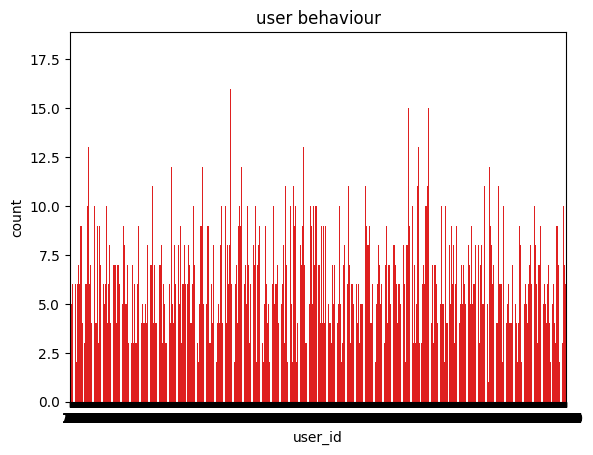

In [26]:
#which user wrote the most reveiws?\
sns.countplot(x="user_id", data=df, color="red")
plt.title("user behaviour")
plt.show()

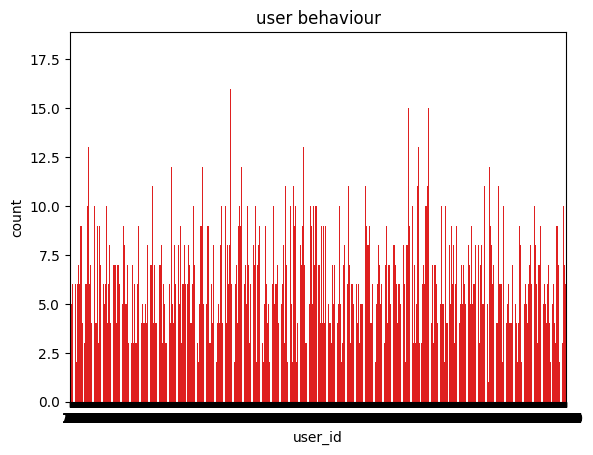

In [27]:
# which users write review frequently?
sns.countplot(x="user_id", data=df, color="red")
plt.title("user behaviour")
plt.show()

In [ ]:
# Which users write reviews for many products?
sns.barplot(x="user_id", y="product_id", data=df, color="red")
plt.title("user behaviour")
plt.show()

In [ ]:
# Which users only write 5-star reviews?
sns.scatterplot(x="user_id", y="rating", data=df, color="red")
plt.title("user behaviour")
plt.show()


In [ ]:
# Which users write mostly negative reviews?
sns.scatterplot(x="user_id", y="review_text", data=df, color="red")
plt.title("user behaviour")
plt.show()

In [ ]:
# Which rating has the highest fake review percentage?
sns.barplot(x="rating", y="fake_probability", data=df, color="red")
plt.title("Rating Distribution")
plt.show()


In [ ]:
# Are fake reviews mostly positive or negative?
sns.scatterplot(x="review_text", y="fake_probability", data=df, color="red")
plt.title("Rating distribution")
plt.show()

In [ ]:
# Which users only write 5-star reviews?
sns.scatterplot(x="user_id", y="rating", data=df, color="red")
plt.title("userbehaviour")
plt.show()

#Product Analysis

Which product has the most reviews?

Which product has the most fake reviews?

Which category has the most fake reviews?


In [ ]:
# Which product has the most reviews?
sns.countplot(x="product_id", data=df, color="red")
plt.AbstractContextManager
plt.title("Product Analysis")
plt.show()

In [ ]:
# Which product has the most fake reviews?
sns.barplot(x="product_id", y="fake_probability", data=df, color="red")
plt.title("product analysis")
plt.show()

In [ ]:
#  has the most fake reviews?
sns.barplot(x="review_id", y="fake_probability", data=df, color="red")
plt.title("product analysis")
plt.show()

Fake vs Real Reviews

In [ ]:
sns.countplot(x="is_fake", data=df)
plt.title("Fake vs Genuine Reviews")
plt.show()

Review Length vs Rating

In [ ]:
sns.boxplot(x="rating", y="review_length", data=df)
plt.title("Review Length vs Rating")
plt.show()

Helpful Votes vs Rating

In [ ]:
sns.scatterplot(x="helpful_votes", y="rating", data=df)
plt.title("Helpful Votes vs Rating")
plt.show()

Fake Review Trend

In [ ]:
df.groupby("review_date")["is_fake"].sum().plot()
plt.title("Fake Review Trend Over Time")
plt.show()

In [ ]:
# Top Fake Review Products
df.groupby("product_id")["is_fake"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Products with Most Fake Reviews")
plt.show()

Fake Review Detection with Deep Learning

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(64, activation="relu"))
model.add(Dense(32, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.fit(x_train, y_train, epochs=5)

Reviewer Network Fraud Detection

In [ ]:
import networkx as nx

G = nx.Graph()

for index,row in df.iterrows():
    G.add_edge(row["user_id"], row["product_id"])

In [ ]:
nx.draw(G, node_size=20)

In [ ]:
df.to_csv("fake_review_predictions.csv",index=False)